In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [7]:
CSV_DIR = Path("/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/predictions/csv")

csv_paths = [
    CSV_DIR / "results_actin-deepict-run6.csv",
    CSV_DIR / "results_actin-deepict-adapted-run8.csv",
]
labels = [
    "actin-deepict-run6",
    "actin-deepict-adapted-run8",
]

Saved: ./actin-deepict-run6_metrics.png


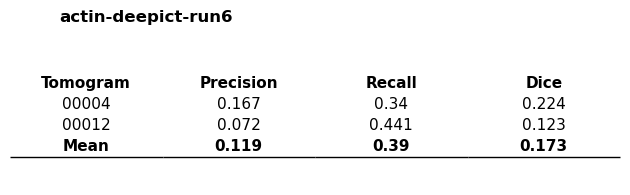

,Precision,Recall,Dice
00004,0.183,0.407,0.253
00012,0.081,0.538,0.140
Mean,0.132,0.473,0.196


Saved: ./actin-deepict-adapted-run8_metrics.png


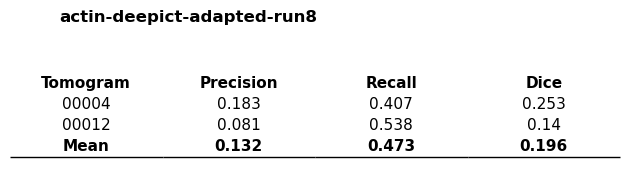

,Precision,Recall,Dice
00004,0.183,0.407,0.253
00012,0.081,0.538,0.140
Mean,0.132,0.473,0.196


In [12]:
# Expected columns: tomogram, precision, recall, dice
import matplotlib.pyplot as plt
import matplotlib as mpl

metrics = ["precision", "recall", "dice"]
output_dir = "./"  # folder to save PNGs

for label, path in zip(labels, csv_paths):
    df = pd.read_csv(path, dtype={"tomogram": str})

    mean_row = df[metrics].mean().to_frame().T
    mean_row.insert(0, "tomogram", "Mean")

    table = pd.concat([df[["tomogram"] + metrics], mean_row], ignore_index=True)
    table[metrics] = table[metrics].round(3)

    col_labels = ["Tomogram", "Precision", "Recall", "Dice"]
    cell_text = table.values.tolist()

    n_rows = len(cell_text)
    n_cols = len(col_labels)

    fig, ax = plt.subplots(figsize=(n_cols * 1.6, (n_rows + 1) * 0.5))
    ax.axis("off")

    t = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
    )
    t.auto_set_font_size(False)
    t.set_fontsize(11)
    t.scale(1, 1.4)

    # Style header row
    for col in range(n_cols):
        cell = t[0, col]
        cell.set_facecolor("white")
        cell.set_text_props(fontweight="bold")
        cell.set_edgecolor("white")
        # top and bottom border on header
        cell.visible_edges = "TB"

    # Style data rows
    for row in range(1, n_rows + 1):
        is_mean = (row == n_rows)
        for col in range(n_cols):
            cell = t[row, col]
            cell.set_facecolor("white")
            cell.set_edgecolor("white")
            cell.visible_edges = "B" if is_mean else "open"
            if is_mean:
                cell.set_text_props(fontweight="bold")
                cell.set_edgecolor("black")

    fig.suptitle(label, fontsize=12, fontweight="bold", x=0.1, ha="left", y=0.95)
    fig.tight_layout()

    out_path = f"{output_dir}{label.replace(' ', '_')}_metrics.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out_path}")
    plt.show()
    
    display(styled)